#  The $H > \frac12$ fBm approx using OU
-------------------------------------------------------------------
In this notebook we will extend the results from OU_simulation.py to the case where $H > \frac12$.

In [1]:
#Import useful functions from last notebook
import numpy as np
import matplotlib.pyplot as plt
from fBm_ou import OU_weights, simulate_OU_paths, simulate_fBm_paths, cov_true_fBm, simulate_BM_paths

# Fractional kernel approximation ($H > \frac12$)

Most of this follows from OU_simulation.py so we skip the details here.

The key part of the OU represntation for fBm uses fact that for $H > \frac12$
$$(t-u)^{H - \frac12} = \frac{1}{\Gamma(\frac12 - H)} \int_0^{\infty} \beta^{-\frac12 - H} (e^{-(t-u)\beta_j} - 1) d \beta$$
Hence we can approximate our kernel $$ K(t,u) = (t - u)^{H - \frac12} \approx \sum_i w_j (e^{-(t-u) \beta_j} - 1) $$ 

We choose a geometric quadrature $\beta_j = r^{j}$ for $r \in (1,2)$ (accounts for the fact that larger $\beta$ is faster mean reverting so shorter time scale ). Note $j = -n + 1, \dots, n$.

So under this discretization we have $$w_j = \frac1{\Gamma \left (\frac12 - H \right) } \int_{r^{j - 1}}^{r^j} x^{-\frac12 - H} dx$$ Hence $$w_j = \frac1{\Gamma(\frac12 - H)} r^{j - 1(\frac12 - H)} \left [ \frac{r^{\frac12 - H} - 1}{\frac12 - H} \right ] $$



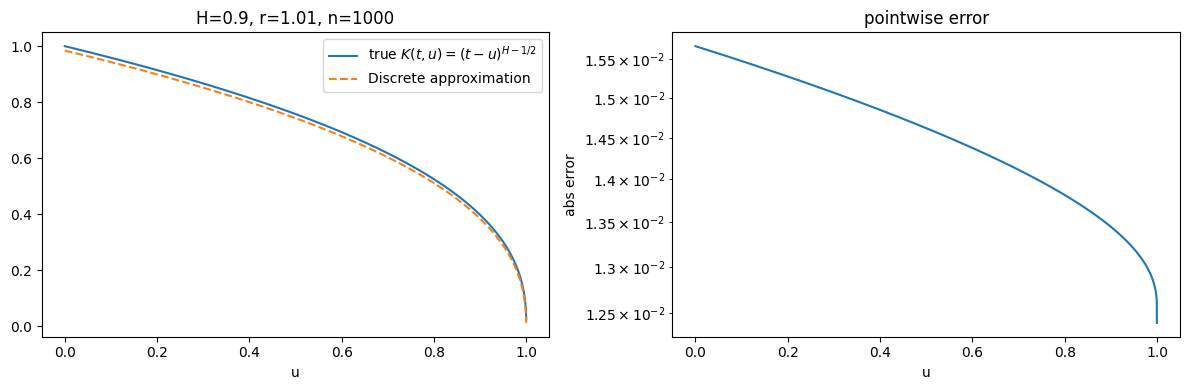

In [5]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

def OU_weights(H, r, n):
    """
    Nodes beta_j = r^{j-1} and weights w_j for j = -n+1,...,n,
    approximating (t-u)^{H-1/2} = (1/Gamma(1/2-H)) * int_0^inf x^{-H-1/2} (e^{-x(t-u)} - 1) dx.
    """
    a = H + 0.5
    j = np.arange(-n + 1, n + 1)          # 2n values: -n+1, ..., n
    beta = r**(j - 1) 
    
    weights = (1/gamma(0.5 - H)) * r**((1 - a)*(j - 1)) * (r**(1 - a) - 1)/(1 - a)
    return beta, weights

def OU_weights_reversed(H, r, n):
    """
    Nodes beta_j = r^{j-1} and weights w_j for j = -n+1,...,n,
    approximating (t-u)^{H-1/2} = (1/Gamma(1/2-H)) * int_0^inf x^{-H-1/2} (e^{-x(t-u)} - 1) dx.
    """
    a = H + 0.5
    j = np.arange(-n + 1, n + 1)          # 2n values: -n+1, ..., n
    beta = r**(1 - j)  # reversed order of beta
    
    weights = (1/gamma(0.5 - H)) * r**((1 - a)*(j - 1)) * (r**(1 - a) - 1)/(1 - a)
    return beta, weights

def kernel_true(t, u, H):
    return (t - u) ** (H - 0.5)

def kernel_approx(t, u, H, n, r):
    beta, weights = OU_weights(H, r, n)  
    du = (t - u)[:, None]                
    return np.sum(weights[None, :] * (np.exp(-beta[None, :] * du) - 1), axis=1)

# --- example ---
H = 0.9
t = 1.0
r = 1.01
n = 1000

u = np.linspace(0, t - 1e-4, 2000)
f_true = kernel_true(t, u, H)
f_hat  = kernel_approx(t, u, H, n, r)
err = np.abs(f_true - f_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(u, f_true, label="true $K(t,u) = (t-u)^{H-1/2}$")
ax1.plot(u, f_hat, '--', label="Discrete approximation ")
ax1.legend()
ax1.set_xlabel("u")
ax1.set_title(f"H={H}, r={r}, n={n}")

ax2.semilogy(u, err)
ax2.set_xlabel("u")
ax2.set_ylabel("abs error")
ax2.set_title("pointwise error")

plt.tight_layout()
plt.show()
    
    

So here we see some major differences from the $H < \frac12$ case since now we don't have any singularity at $t = u$ so there is no blowup.

# Simulating fBm using OU ($H > \frac12$)
Note that for $H > \frac12$:
$$B_t^H= \bar{c}_H \int_0^{\infty} \beta^{-1 / 2-H}\left(Z_t^\beta-Z_0^\beta - B_t \right) d \beta$$
where $B_t$ is a standard Brownian motion.
So we discretize this using
$$B_t^{H, n} = \sum_{j = 0}^n w_j (Z^{\beta_i}_t - {Z^{\beta_i}_0} - B_t)$$

Which allows us to use the same weights as from the previous markdown. Thus in order to simulate paths in this way we will employ the weights from the previous markdown and use the same method for generating the values of $Z_t^{\beta}$ from the first (top) markdown. Note that we easily simulate our standard BM path simultaneously with the OU process as it is the same underlying driving BM.

In [3]:
def simulate_fBm_paths_largeH(H, r, n, T, n_steps, M, rng):
    from scipy.special import gamma
    
    beta, w = OU_weights(H, r, n)
    sum_w = np.sum(w)
    print(f"sum of weights = {sum_w:.4f}")
    
    #cH = np.sqrt(2*H * gamma(1.5 - H) / (gamma(H + 0.5) * gamma(2 - 2*H)))
    
    Z_path, W = simulate_OU_paths(beta, T, n_steps, M, rng,
                                   stationary_start=True,
                                   return_brownian=True)
    
    B_raw = Z_path @ w
    return B_raw - B_raw[:, [0]] - sum_w * W

sum of weights = -0.0394
sum of weights = -0.3730
sum of weights = -1.1786


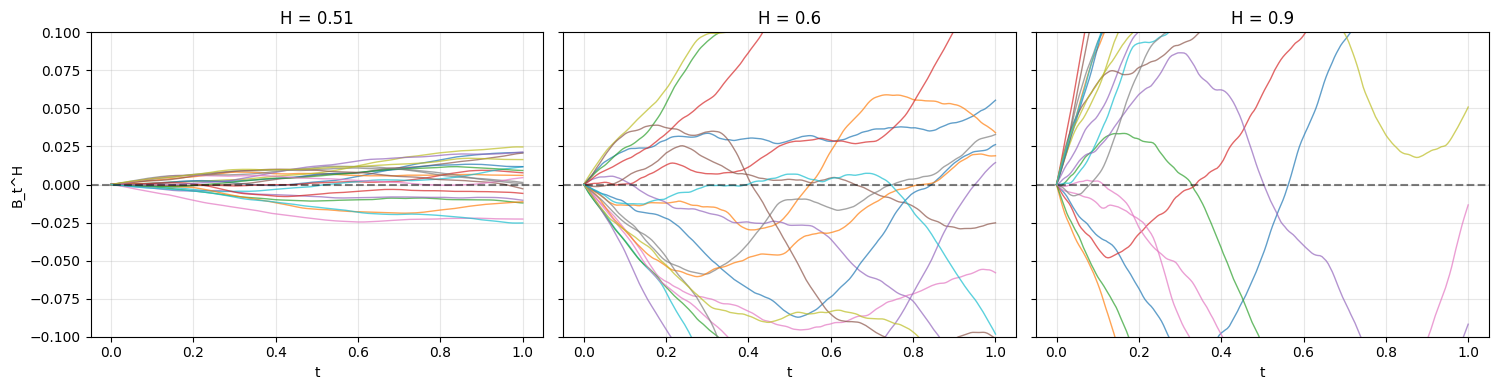

In [4]:
# ---------- Simulation parameters ----------
T = 1
n_steps = 200      # fine time grid to see roughness
r = 1.02
n = 100  # many β nodes down to β_min ~ 1e-9
M_per_H = 20             # number of paths per H value

# Create a random generator with a fixed seed for reproducibility
rng = np.random.default_rng(42)

# Time points
times = np.linspace(0, T, n_steps + 1)

# Choose the Hurst parameters to compare
H_values = [0.51, 0.6, 0.9]

# ---------- Plotting ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, H in enumerate(H_values):
    # Simulate M paths for this H
    paths = simulate_fBm_paths_largeH(H, r, n, T, n_steps, M_per_H, rng)

    # Plot each path with a slight transparency
    for m in range(M_per_H):
        axes[idx].plot(times, paths[m], alpha=0.7, linewidth=1)

    axes[idx].set_title(f'H = {H}')
    axes[idx].set_xlabel('t')
    axes[idx].grid(alpha=0.3)
    axes[idx].axhline(0, color='black', linestyle='--', alpha=0.5)

axes[0].set_ylabel('B_t^H')
plt.tight_layout()
plt.ylim(-0.1,0.1)
plt.show()

### Why the geometric grid struggles for H > 1/2, and how the log-spaced grid fixes it

The geometric grid places nodes at $\beta_j = r^{j-1}$ for $j=-n+1,\dots,n$, so its total range is fixed by the step ratio $r$ and node count $n$: $[\,r^{-n+1},\, r^{n}\,]$. For $r$ close to $1$ (needed for fine, accurate local resolution of the density), each step barely moves you, so reaching a wide range of $\beta$ - in particular large $\beta$, corresponding to fast mean-reversion / short time-scales - requires a very large number of nodes $n$. With a modest, practical choice of $(r,n)$, the grid ends up covering only a fairly narrow band of $\beta$ values, and in particular can fail to reach large enough $\beta$ to resolve the short time-scale behaviour the kernel needs (especially important for $H>\tfrac12$, where under-resolving large $\beta$ causes the fast-mean-reverting terms to be lost, producing paths that are artificially smooth).

Essentially  with the geometric grid there is a tension between fine local resolution (small $r$) and reaching a wide enough range (needing many nodes $n$ to get there) - and a fixed, modest node budget forces a compromise that can leave large $\beta$ under-resolved.

The log-spaced grid avoids this by fixing the range directly, based on the time-scales the simulation can actually resolve:
$$\beta_{\min} = \frac{1}{T}, \qquad \beta_{\max} = \frac{1}{dt},$$
and then distributing a fixed number of nodes $N_\beta$ evenly in log-space across exactly this range. Since the range is guaranteed to reach $\beta_{\max}=1/dt$ regardless of how many nodes are used, the fast-mean-reverting terms are always included, rather than needing a careful (and expensive) choice of $r,n$ to reach them

In [5]:
def OU_weights_logspace(H, T, dt, N_beta):
    """
    Build beta nodes (log-spaced over [1/T, 1/dt]) and matching quadrature
    weights approximating

        (t-u)^{H-1/2} = (1/Gamma(1/2-H)) * int_0^inf beta^{-1/2-H} (e^{-beta(t-u)} - 1) dbeta

    for H > 1/2, using the same underlying identity as OU_weights, but
    with nodes chosen directly on a log grid instead of a fixed-ratio
    geometric sequence beta_j = r^j. This avoids the extreme weight decay
    at large beta_j noted in Cell 8.

    Each weight w_i is the exact mass of the density beta^{-a} over the
    cell between beta_{i-1} and beta_i, using the antiderivative

        int beta^{-a} dbeta = beta^{1-a} / (1-a).

    Parameters
    ----------
    H : float
        Hurst parameter, in (1/2, 1).
    T : float
        Total time horizon -- sets the smallest resolvable rate, 1/T.
    dt : float
        Time step -- sets the largest resolvable rate, 1/dt.
    N_beta : int
        Number of beta nodes.

    Returns
    -------
    beta : ndarray, shape (N_beta,)
    w    : ndarray, shape (N_beta,)
    """
    a = H + 0.5
    beta_min, beta_max = 1.0 / T, 1.0 / dt
    beta = np.logspace(np.log10(beta_min), np.log10(beta_max), N_beta)

    w = np.zeros(N_beta)

    # First node: carries the mass of the density from 0 up to beta[0].
    w[0] = beta[0]**(1 - a) / (1 - a)

    # Middle nodes: node i carries the mass between beta[i-1] and beta[i].
    for i in range(1, N_beta):
        w[i] = (beta[i]**(1 - a) - beta[i-1]**(1 - a)) / (1 - a)

    # Last node: also absorb the tail mass from beta[-1] out to infinity.
    tail_mass = -beta[-1]**(1 - a) / (1 - a)
    w[-1] = w[-1] + tail_mass

    # Overall normalising constant from the original kernel identity.
    w = w / gamma(0.5 - H)

    return beta, w


Text(0.5, 1.0, 'Weight magnitude vs. beta: geometric vs. log-spaced grid')

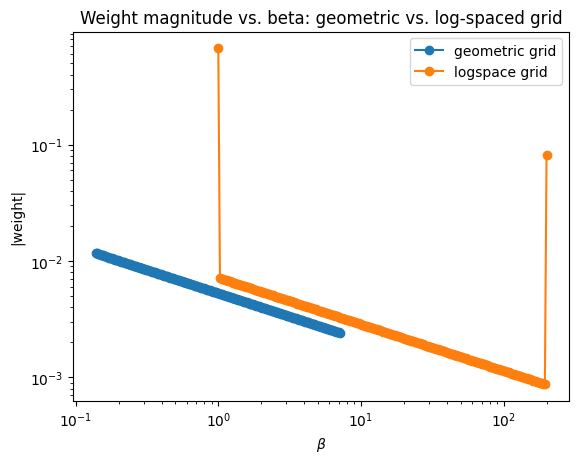

In [6]:

beta_geo, w_geo = OU_weights(H, r=1.02, n=100)
beta_log, w_log = OU_weights_logspace(H, T=1.0, dt=1.0/200, N_beta=200)

plt.loglog(beta_geo, np.abs(w_geo), 'o-', label='geometric grid')
plt.loglog(beta_log, np.abs(w_log), 'o-', label='logspace grid')
plt.xlabel(r'$\beta$'); plt.ylabel('|weight|')
plt.legend()
plt.title('Weight magnitude vs. beta: geometric vs. log-spaced grid')

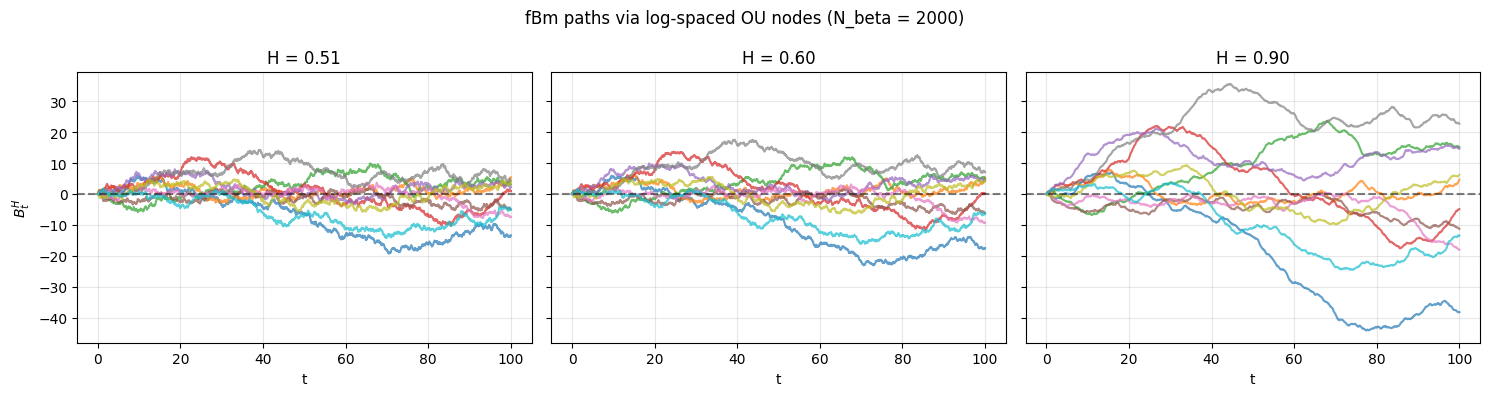

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# --------------------------------------------------------------------------
# Alternative node/weight construction for H > 1/2

def simulate_fBm_paths_largeH(H, T, n_steps, N_beta, M, rng):
    """
    Simulate M sample paths of stationary fBm for H > 1/2, via the
    Muravlev representation:

        B_t^H = c_H * int beta^{-1/2-H} (Z_t^beta - Z_0^beta - B_t) dbeta

    using the log-spaced nodes/weights above, but reusing the existing,
    already-validated `simulate_OU_paths` machinery (correlated stationary
    start, shared driving noise across all beta_j and the Brownian path)
    from fBm_ou.py -- no need to re-implement the OU recursion or the
    Cholesky step here.

    Returns
    -------
    B : ndarray, shape (M, n_steps+1)
    times : ndarray, shape (n_steps+1,)
    """
    dt = T / n_steps
    beta, w = OU_weights_logspace(H, T, dt, N_beta)
    sum_w = np.sum(w)

    Z_path, W = simulate_OU_paths(beta, T, n_steps, M, rng,
                                   stationary_start=True, return_brownian=True)

    B_raw = Z_path @ w                 # sum_j w_j * Z_t^{beta_j}
    B = B_raw - B_raw[:, [0]] - sum_w * W   # subtract Z_0 term and B_t term
    times = np.linspace(0, T, n_steps + 1)
    return B, times


# ---------- Example usage ----------

H = [0.55, 0.7, 0.95]
T = 100.0
n_steps = 5000
N_beta = 2000
n_paths = 10
seed = 42

fig, axes = plt.subplots(1, len(H_values), figsize=(5 * len(H_values), 4), sharey=True)

for idx, H in enumerate(H_values):
    rng = np.random.default_rng(seed)
    B, times = simulate_fBm_paths_largeH(H, T, n_steps, N_beta, n_paths, rng)

    for m in range(n_paths):
        axes[idx].plot(times, B[m], alpha=0.7)

    axes[idx].set_title(f'H = {H:.2f}')
    axes[idx].set_xlabel('t')
    axes[idx].grid(alpha=0.3)
    axes[idx].axhline(0, color='black', linestyle='--', alpha=0.5)

axes[0].set_ylabel(r'$B_t^H$')
fig.suptitle(f'fBm paths via log-spaced OU nodes (N_beta = {N_beta})')
plt.tight_layout()
plt.show()

# Validation

We copy the validation method from the last notebook and include it here for reference. We validate that this is indeed (approximately) true fBm by checking the covariance. We do this by via monte carlo methods to calculate the covariance structure. In particular we simulate $M$ ($= 5000$) sample paths and create a monte carlo estimate of the covariance matrix using the following idea: 
$$C(i,j) = \operatorname{cov}(B_{t_i}^{H}, B_{t_j}^{H}) = \mathbb{E}[B_{t_i}^{H}, B_{t_j}^{H}]$$
So our monte carlo approximate covariance matrix is
$$ \hat{C}[i,j] = \frac{1}{M}\sum_{m=1}^{M} B_{\text{all}}[m,i] \cdot B_{\text{all}}[m,j] = \frac{1}{M}\left(B_{\text{all}}^{\top} B_{\text{all}}\right)[i,j] $$

In [8]:
import numpy as np

H = 0.7
T = 1.0
n_steps = 200
N_beta = 100
M = 5000

rng = np.random.default_rng(0)
B_all, times = simulate_fBm_paths_largeH(H, T, n_steps, N_beta, M, rng)   # shape (M, n_steps+1)

C_hat = (B_all.T @ B_all) / M      # shape (n_steps+1, n_steps+1)

We next normalize to ensure scaling/constants match the theoretical (fBm scaling is a bit fiddly so we fix it here).

In [9]:
target_var_at_t1 = 1.0**(2*H)     # = 1, from Var(B_t^H) = t^{2H}
empirical_var_at_t1 = C_hat[-1, -1]    # assuming T=1, last index is t=1
scale_correction = np.sqrt(target_var_at_t1 / empirical_var_at_t1)

B_all_calibrated = B_all * scale_correction
C_hat = (B_all_calibrated.T @ B_all_calibrated) / M

Reference covariance

In [10]:
def cov_true_fBm(s, t, H):
    return 0.5 * (s**(2*H) + t**(2*H) - abs(s - t)**(2*H))

C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])

Comparison

max abs error: 0.18301098810024935
max rel error: 1.6339264599899115


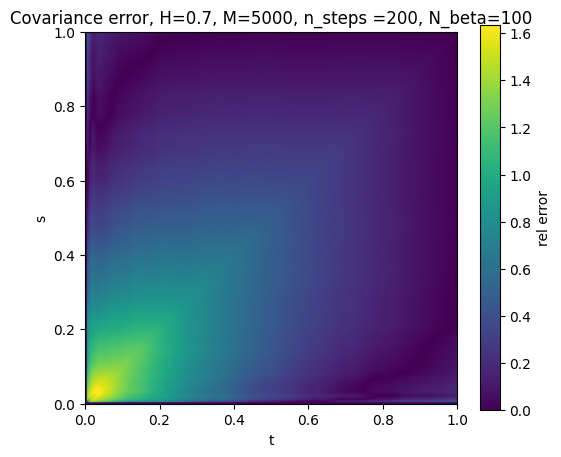

In [11]:
abs_err = np.abs(C_hat - C_true)
rel_err = abs_err / (np.abs(C_true) + 1e-10)

print("max abs error:", abs_err.max())
print("max rel error:", rel_err.max())

plt.figure(figsize=(6,5))
plt.imshow(rel_err, origin='lower', extent=[0, T, 0, T])
plt.colorbar(label="rel error")
plt.title(f"Covariance error, H={H}, M={M}, n_steps ={n_steps}, N_beta={N_beta}")
plt.xlabel("t"); plt.ylabel("s")
plt.show()

We notice two key behaviors here:

- Along the diagonal $s \approx t$ we have a large error. this is because of the singularity in our fractional kernel since $Cov(B_s,B_t) = \int f_s(u)f_t(u) du$ where $f_s, f_t$ are our frational kernels that (as we saw above) are bad approximations near the singualirties $s = u$ and $t = u$, hence when $s = t = u$ we have a compound of these bad singularities which causes this large error.

- For small $s$ or small $t$ our covariances has a larger relative error, this is likely to be caused by the fact that the covariance is very small for smaller $s,t$ which would result in larger relative error.

In [12]:
def max_cov_error(H, r, n, T, n_steps, M, rng):
    B = simulate_fBm_paths_largeH(H, r, n, T, n_steps, M, rng)
    C_hat = (B.T @ B) / M
    scale = np.sqrt(1.0 / C_hat[-1,-1])   # calibrate using t=T=1 point
    C_hat *= scale**2
    times = np.linspace(0, T, n_steps+1)
    C_true = np.array([[cov_true_fBm(si,tj,H) for tj in times] for si in times])
    return np.abs(C_hat - C_true).max()

ns = [10, 20, 40, 80, 160]
errors = []
for nn in ns:
    rr = 1 + 1/nn      # shrink r as n grows, tie them together sensibly
    e = max_cov_error(H, rr, nn, T, n_steps, M, np.random.default_rng(nn))
    errors.append(e)

plt.figure()
plt.loglog(ns, errors, 'o-')
plt.xlabel("n (number of OU rates, half-grid)")
plt.ylabel("max abs covariance error")
plt.title(f"Covariance convergence, H={H}")
plt.grid(True, which='both', alpha=0.3)
plt.show()

TypeError: simulate_fBm_paths_largeH() takes 6 positional arguments but 7 were given

As we expect the covariance converges. However it unexpectedly goes back up. This because when our quadrature points becomes very close $\beta_i \approx beta_j$ our covariance cholesky matrix for OU  process $Z_0$ is $\Gamma_{i,j} = \frac1{\beta_i + \beta_j}$ will begin to become ill-condiitoned and have linearly dependent columns`which makes the cholesky decomposition algorithm break down.

In [ ]:
for nn in ns:
    rr = 1 + 1/nn
    beta, w = OU_weights(H, rr, nn)
    Gamma = 1.0 / (beta[:,None] + beta[None,:])
    print(f"n={nn:4d}  cond(Gamma) = {np.linalg.cond(Gamma):.3e}")

n=  10  cond(Gamma) = 4.724e+18
n=  20  cond(Gamma) = 7.695e+19
n=  40  cond(Gamma) = 1.810e+19
n=  80  cond(Gamma) = 6.391e+19
n= 160  cond(Gamma) = 1.317e+20
